# **EDA, ML, and Integration with Teammates (Finding Synergies) M3 Phase**

By: Allison Kramer


**Domain Question 4:** What underlying patterns emerge in how federal agencies structure and distribute grant funding?


**Problem Statement:**

This analysis explores underlying patterns in how federal agencies structure and distribute grant funding. Identifying these patterns can reveal whether agencies prioritize broad access, high-impact funding, or specialized initiatives. It can allow for insight into if they are favoring certain profiles over others - allowing for reflecton on if they should be investing more funding elsewhere. Its key to distinguish this question is comparing agencies and not individual opportunities.

While initial EDA provided a broad understanding of the dataset, additional targeted exploration was conducted to identify features most relevant for detecting agency-level funding strategy profiles.

### **What Changed Since M2 Submission:**

**1. Preprocessing Validation**

Tested Drop NAs vs Fill with 0 across k=2-8 using silhouette scores
Fill with 0 showed artificially high score at k=2 (0.516) that collapsed at k=3 (0.29). Confirmed dropping NAs as the methodologically sound approach

**2. Integration with Teammates**

- Anna (Temporal Eras): Quantified agency profile shifts across eras - High Opportunity declined 84%→74% post-2018
- Sambisha (Eligibility): Calculated eligibility breadth - High Opportunity agencies allow 9.04 types vs 1.48 for Lower Funding
- Maggie (Categories): Created heatmap showing High Opportunity concentrates in health/education while High Funding spreads broadly**

**3. New Visualizations**

Era comparison bar chart (agency profiles across time)
Eligibility breadth boxplot (inclusivity by funding strategy)
Category distribution heatmap (agency clusters × grant categories)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

grants = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv")

details = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grant_opportunity_details.csv")

/tmp/ipython-input-2463505631.py:5: DtypeWarning: Columns (6,8,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  grants = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-10-03/grants.csv")


In [2]:
print(f"Grants: ", grants.shape)
print(f"Details: ", details.shape)

Grants:  (74669, 17)
Details:  (2000, 68)


In [3]:
grants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74669 entries, 0 to 74668
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   opportunity_id                  74669 non-null  int64  
 1   opportunity_number              74669 non-null  object 
 2   opportunity_title               74669 non-null  object 
 3   agency_code                     74626 non-null  object 
 4   agency_name                     74625 non-null  object 
 5   estimated_funding               53043 non-null  float64
 6   expected_number_of_awards       53371 non-null  object 
 7   grantor_contact                 74638 non-null  object 
 8   agency_contact_phone            668 non-null    object 
 9   agency_contact_email            73791 non-null  object 
 10  estimated_post_date             517 non-null    object 
 11  estimated_application_due_date  574 non-null    object 
 12  posted_date                     

In [4]:
details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 68 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   opportunity_id                                                       2000 non-null   int64  
 1   funding_opportunity_number                                           2000 non-null   object 
 2   funding_opportunity_title                                            2000 non-null   object 
 3   opportunity_category                                                 2000 non-null   object 
 4   opportunity_category_explanation                                     53 non-null     object 
 5   expected_number_of_awards                                            619 non-null    float64
 6   cost_sharing_or_matching_requirement                                 2000 non-null   bool   
 7   versio

## **EDA: Pre-Clustering Diagnostics** (Keeping what is neccessary for Integration and Synergy)

This exploratory analysis focuses on identifying whether federal agencies exhibit distinct funding strategy profiles based on funding scale, award volume, and reporting behavior.

### **1. Missing Data Assessment**
Understanding missing data patterns is good when comparing agency strategies, as uneven reporting may distort funding comparisons.

In [5]:
# Examining whether funding data is missing systematically across agencies

# Missing Funding Rate by Agency (Top 15 Agencies by Volume)

top_agencies = grants['agency_name'].value_counts().head(15).index

missing_by_agency = (grants[grants['agency_name'].isin(top_agencies)]
                     .groupby('agency_name')['estimated_funding']
                     .apply(lambda s: s.isna().mean())
                     .sort_values(ascending=False))

missing_by_agency


,estimated_funding
agency_name,
NASA Headquarters,0.975355
National Institutes of Health,0.724353
Geological Survey,0.266551
Centers for Disease Control and Prevention,0.199189
Department of Commerce,0.141230
Department of Education,0.134831
National Science Foundation,0.057273
National Park Service,0.054237
Fish and Wildlife Service,0.038574


NASA Headquarters and National Institutes of Health has over a lot missing - it will effect comparability. NASA → ~97% missing & NIH → ~72% missing

### **2. Agency-Level Aggregation**
Constructing Agency Level Profiles

Because this research question focuses on agency strategy rather than individual opportunities, grant level data was aggregated to construct agency level summaries.


In [6]:
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

In [7]:
agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

agency_profile.sort_values('n_opps', ascending=False).head(10)

,agency_name,n_opps,avg_funding,med_funding,avg_awards,med_awards,funding_missing_rate
336,National Institutes of Health,11239,6.244770e+06,3000000.0,3924.891850,4.0,0.724353
338,National Park Service,8426,5.961203e+05,61000.0,186.935621,1.0,0.054237
209,Fish and Wildlife Service,4122,1.646400e+06,99000.0,166.960866,1.0,0.038574
78,Bureau of Land Management,2868,8.687874e+05,200000.0,776.749605,1.0,0.015690
221,Geological Survey,2311,4.645448e+05,75749.0,2.245690,1.0,0.266551
123,Centers for Disease Control and Prevention,1727,2.230190e+07,2122500.0,5682.843858,1.0,0.199189
233,Health Resources and Services Administration,1609,3.813759e+07,3070300.0,30.627488,8.0,0.005594
167,Department of Education,1513,9.723368e+07,3750000.0,8630.163985,8.0,0.134831
181,Dept. of the Army -- USAMRAA,1507,1.044582e+07,4800000.0,8.691739,4.0,0.013271
198,Environmental Protection Agency,1371,2.949487e+07,2000000.0,20.399113,8.0,0.001459


**Substantial variation emerges across agencies in both funding scale and award volume. Some agencies appear to distribute fewer, larger awards, while others fund a greater number of smaller opportunities. These early patterns provide preliminary evidence that agencies may operate under distinct funding strategies.**

**Because the research question is inherently agency-level, clustering will be performed on aggregated features rather than individual opportunities to ensure that inferred strategy profiles reflect institutional behavior rather than grant-level noise.**

### **3. Defining Features**

In [8]:
import numpy as np

features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Make sure features exists
print(features.shape)


(659, 4)


## **Unsupervised Machine Learning M3 Phase**

### **1. Preparing Data for Clustering**



In [9]:
agency_profile.columns

Index(['agency_name', 'n_opps', 'avg_funding', 'med_funding', 'avg_awards',
       'med_awards', 'funding_missing_rate'],
      dtype='object')

In [10]:
import numpy as np

# Choosing my Features
features = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Create Log Features --> directly into dataframe
features.loc[:, 'log_n_opps'] = np.log1p(features['n_opps'])
features.loc[:, 'log_med_funding'] = np.log1p(features['med_funding'])
features.loc[:, 'log_med_awards'] = np.log1p(features['med_awards'])

# Final Feature Set Before Clustering
features = features[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']].copy()

**To capture agency funding strategy, clustering was performed on four dimensions: opportunity volume (n_opps), typical funding level (med_funding), award size (med_awards), and reporting consistency (funding_missing_rate). Together, these variables approximate how aggressively and transparently agencies distribute federal funding.**

In [11]:
# KMeans cannot handle NaNs, rows with missing data will be removed for clustering
features.isna().sum().sort_values(ascending=False)
features_clean = features.dropna()

In [12]:
#Scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_clean)

### **2. Determining the Optimal Number of Clusters**

**Find K - Elbow and Silhoutte**

**1. Elbow**

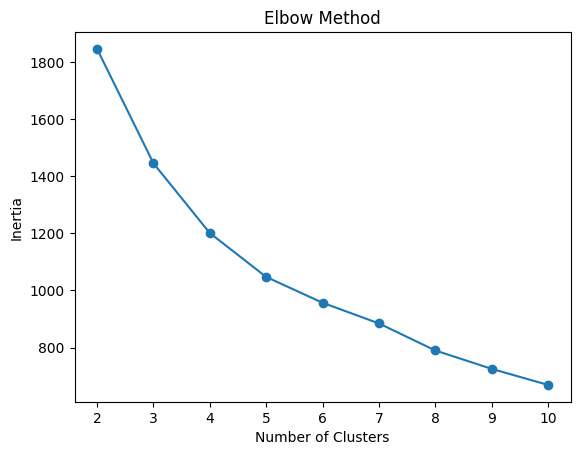

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

**The elbow begins forming around k=4, suggesting that 4 clusters likely capture the primary structure before marginal improvements diminish.**

**2. Silhoutte**

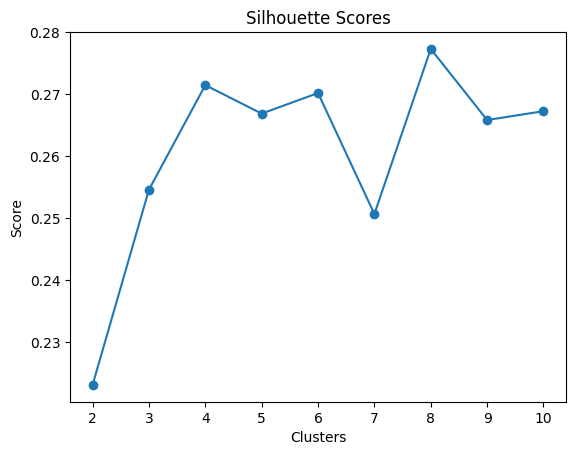

In [14]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,11), scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Clusters")
plt.ylabel("Score")
plt.show()

**Although silhouette scores were slightly higher at larger k values, additional clusters created fragmented groups that were difficult to interpret strategically. A four cluster solution provided the best balance between statistical fit and practical interpretability.**

### **3. Fitting Model**

In [15]:
#Running K-Means & Picking 4 as my k

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

#Attatch Cluster Labels to Agencies
agency_profile_clean = agency_profile.loc[features_clean.index].copy()
agency_profile_clean['cluster'] = clusters


In [16]:
#Profile the Clusters

cluster_summary = agency_profile_clean.groupby('cluster')[['n_opps',
                                                           'med_funding',
                                                           'med_awards',
                                                           'funding_missing_rate'
                                                           ]].median()

cluster_summary

,n_opps,med_funding,med_awards,funding_missing_rate
cluster,,,,
0,7.0,225000.0,3.0,0.083333
1,24.0,3000000.0,1.0,0.583333
2,11.0,11250000.0,40.0,0.037037
3,145.5,1650000.0,2.0,0.116531


In [17]:
#Seeing if What Was Removed Would Impact Clustering

print("Original Amount:", len(features))
print("After dropna:", len(features_clean))

amount_removed = len(features) - len(features_clean)
print(f"Amount Removed: ", amount_removed)

pct_removed = 1 - (len(features_clean) / len(features))
print(f"Percent Removed: %", round(pct_removed, 4)*100)

Original Amount: 659
After dropna: 592
Amount Removed:  67
Percent Removed: % 10.17


**Approximately 10% of agencies were removed due to missing values. Because the majority of observations were retained, the risk of systematic bias in the clustering results is likely low.**

### **4. Visualizing the Clusters / Interpreting the Model**

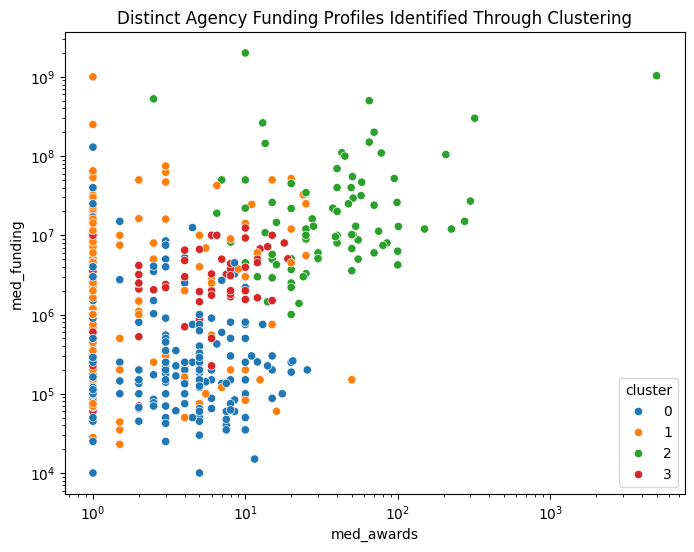

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=agency_profile_clean,
    x='med_awards',
    y='med_funding',
    hue='cluster',
    palette='tab10'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Distinct Agency Funding Profiles Identified Through Clustering")
plt.show()


**Breif Interpretation:** **The Green Cluster:** mostly high funding along with higher awards, likely major funding agencies. **The Blue Cluster:** lower funding and lower awards, probably smaller agencies. **The Red Cluster:** mid range funding with not a huge counts, likely for possible specialized grants. **The Orange Cluster:** its pretty spread across funding levels, but it looks like lower awards so maybe inconsistent funding strategies for this cluster is present.

In [19]:
# Assign descriptive labels for interpretability
cluster_labels = {
    0: "Lower Funding / Smaller Awards",
    1: "Moderate Funding, Few Awards",
    2: "High Funding Agencies",
    3: "High Opportunity Agencies"}

agency_profile_clean['cluster_label'] = agency_profile_clean['cluster'].map(cluster_labels)

In [20]:
# Checking Table for Cluster Amount

cluster_profile = agency_profile_clean.groupby('cluster').agg({'n_opps':'median',
                                                               'med_funding':'median',
                                                               'med_awards':'median',
                                                               'funding_missing_rate':'median'})

cluster_profile['cluster_size'] = agency_profile_clean['cluster'].value_counts()

cluster_profile.sort_index()


,n_opps,med_funding,med_awards,funding_missing_rate,cluster_size
cluster,,,,,
0,7.0,225000.0,3.0,0.083333,235
1,24.0,3000000.0,1.0,0.583333,166
2,11.0,11250000.0,40.0,0.037037,91
3,145.5,1650000.0,2.0,0.116531,100


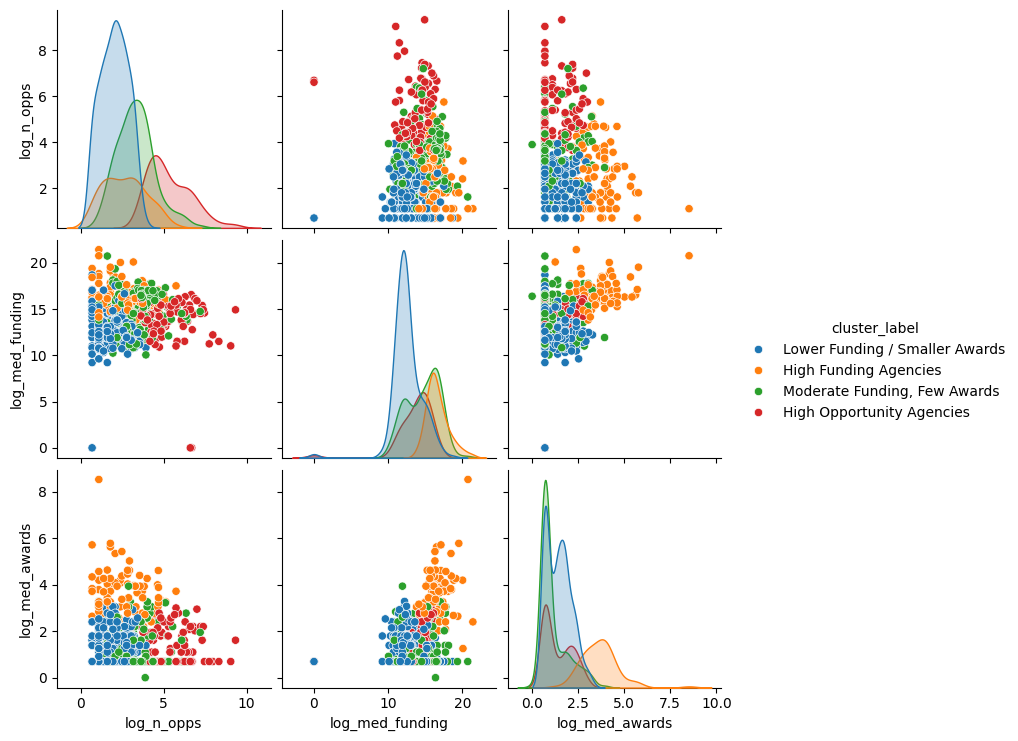

In [21]:
plot_df = features_clean.copy()
#plot_df['cluster'] = agency_profile_clean['cluster']
plot_df['cluster_label'] = agency_profile_clean['cluster_label']

sns.pairplot(
    plot_df,
    vars=['log_n_opps','log_med_funding','log_med_awards'],
    hue='cluster_label',
    palette='tab10'
)

plt.show()



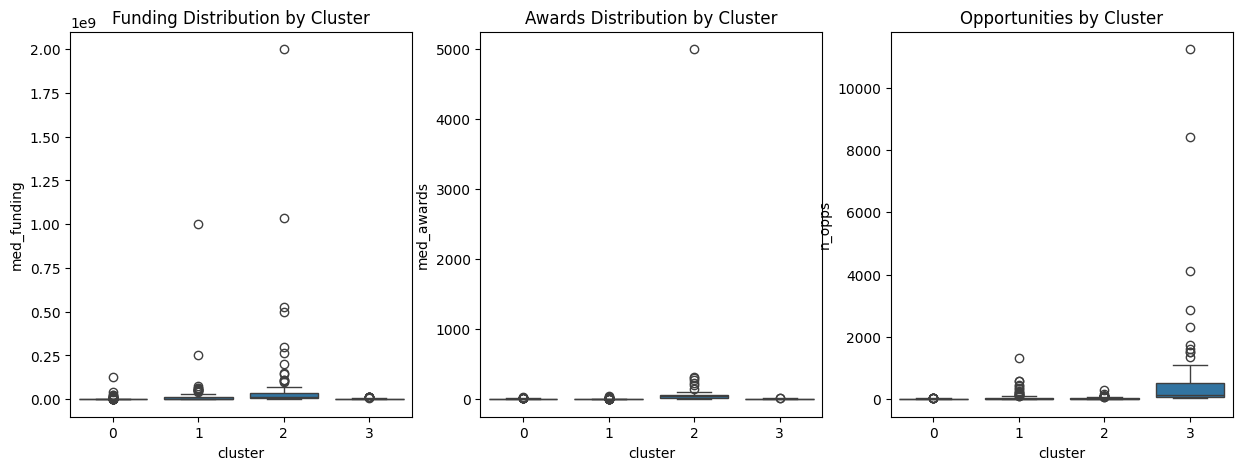

In [22]:
fig, axes = plt.subplots(1,3, figsize=(15,5))

sns.boxplot(data=agency_profile_clean, x='cluster', y='med_funding', ax=axes[0])
axes[0].set_title("Funding Distribution by Cluster")

sns.boxplot(data=agency_profile_clean, x='cluster', y='med_awards', ax=axes[1])
axes[1].set_title("Awards Distribution by Cluster")

sns.boxplot(data=agency_profile_clean, x='cluster', y='n_opps', ax=axes[2])
axes[2].set_title("Opportunities by Cluster")

plt.show()

**The clustering analysis reveals distinct agency funding strategies rather than perfectly separated groups. One cluster is characterized by substantially higher funding levels and award counts, indicating large scale funding institutions. Another cluster demonstrates high opportunity volume with more moderate funding levels, suggesting a strategy focused on distributing resources across many programs. Meanwhile, smaller clusters represent agencies with lower funding footprints, likely reflecting specialized or niche funding priorities. The presence of some overlap is expected in real-world financial data and reinforces that agency behaviors exist along a spectrum rather than within rigid boundaries.**

# **Integrations for M3**

## **1) Seeing if Dropping or Filling N/A's Produce Better Insights**

### Preproccessing Experiment: (Sambisha, Maggies, Anna Decision)

**In M2, the elbow method was used to determine the optimal number of clusters (k=4). For M3 integration, I used silhouette scores as a baseline for preprocessing experimentation in order to compare whether dropping NAs or filling with zeros produced a better cluster structure. This told me which preprocessing decision was better rather than focusing on the choice of k, which remained consistent with M2 findings.**

In [23]:
# Importing everything again in case
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-inputing my agency profile code (what I did before above)
grants['expected_awards_num'] = pd.to_numeric(grants['expected_number_of_awards'], errors='coerce')

agency_profile = (grants.groupby('agency_name')
                  .agg(
                      n_opps=('opportunity_id','count'),
                      avg_funding=('estimated_funding','mean'),
                      med_funding=('estimated_funding', 'median'),
                      avg_awards=('expected_awards_num','mean'),
                      med_awards=('expected_awards_num', 'median'),
                      funding_missing_rate=('estimated_funding', lambda s: s.isna().mean())
                  )
                  .reset_index())

In [24]:
# FIRST OPTION
features_A = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

features_A['log_n_opps'] = np.log1p(features_A['n_opps'])
features_A['log_med_funding'] = np.log1p(features_A['med_funding'])
features_A['log_med_awards'] = np.log1p(features_A['med_awards'])

features_A = features_A[['log_n_opps', 'log_med_funding', 'log_med_awards', 'funding_missing_rate']]

features_A_clean = features_A.dropna()

#^this is all same code from M2 - just renamed features variable for easier interpretation

In [25]:
#SECOND OPTION:

# Fill NAs with 0 (What Maggie, Sambisha, and Anna did)
features_B = agency_profile[['n_opps', 'med_funding', 'med_awards', 'funding_missing_rate']].copy()

# Fill BEFORE log transform
features_B['med_funding'] = features_B['med_funding'].fillna(0)
features_B['med_awards'] = features_B['med_awards'].fillna(0)

features_B['log_n_opps'] = np.log1p(features_B['n_opps'])
features_B['log_med_funding'] = np.log1p(features_B['med_funding'])
features_B['log_med_awards'] = np.log1p(features_B['med_awards'])

features_B = features_B[['log_n_opps', 'log_med_funding','log_med_awards', 'funding_missing_rate']]
features_B_clean = features_B.dropna()

In [26]:
# Seeing exactly how many is kept - tested in percent form before
print("Option A (Drop NAs) - agencies retained:", len(features_A_clean))
print("Option B (Fill 0s) - agencies retained:", len(features_B_clean))
print("Difference:", len(features_B_clean) - len(features_A_clean), "extra agencies")

Option A (Drop NAs) - agencies retained: 592
Option B (Fill 0s) - agencies retained: 659
Difference: 67 extra agencies


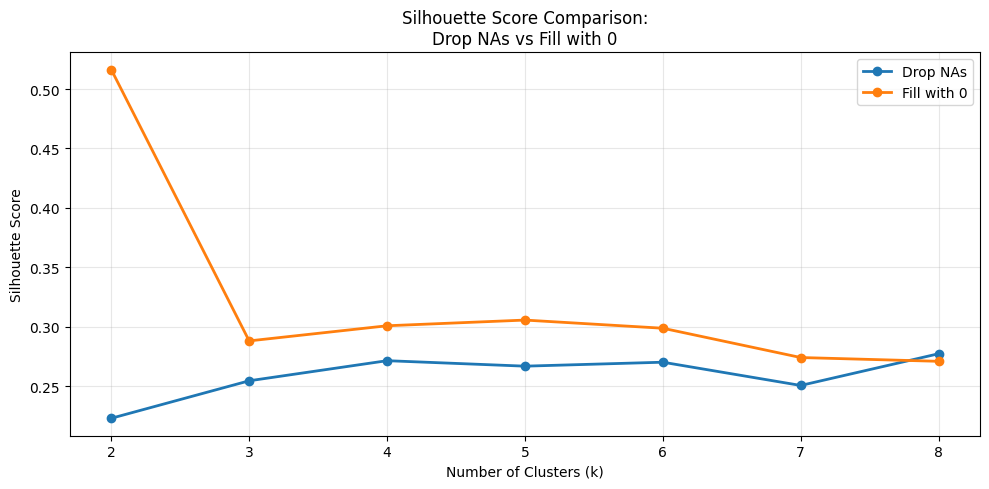


Best silhouette scores:
    k       method  silhouette  n_agencies
12  8     Drop NAs    0.277336         592
1   2  Fill with 0    0.516377         659


In [27]:
# Compare Silhouette Scores Across k for BOTH options
results = []

for k in range(2, 9):
    for name, features in [("Drop NAs", features_A_clean),
                            ("Fill with 0", features_B_clean)]:
        scaler = StandardScaler()
        X = scaler.fit_transform(features)
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        score = silhouette_score(X, labels)
        results.append({'k': k, 'method': name, 'silhouette': score,'n_agencies': len(features)})

results_df = pd.DataFrame(results)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))

for method, group in results_df.groupby('method'):
    ax.plot(group['k'], group['silhouette'],
            marker='o', label=method, linewidth=2)

ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score Comparison:\nDrop NAs vs Fill with 0")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest silhouette scores:")
print(results_df.loc[results_df.groupby('method')['silhouette'].idxmax()])

**I think filling with 0's can actually be misleading when interpreting the optin b silhoutte score. It gave a high silhouette score of 0.516 at k=2, but then dropped to 0.29 at k=3. This can suggest that the initial structure was not capturing real agency differences and instead seperated those agencies with missing data (what we filled) from those with reported funding  but rather simply separating agencies with missing data from those with reported funding. Even though the Silhoutte Score with dropping n/a's here produced a lower score ranging from 0.22 to 0.28, I still think it is a better indicator of meaningful cluster structures.**

**When I looked deeper into the data again, agencies such as NASA had around 97% of their funding data missing, but here in option B they would be cateogrixzed as low funding agencies only because their data was not reported which can be false realistically.**

## **2) Maggies Clustering**

**Maggies Code (Data Cleaning)**

In [28]:
import pandas as pd
import numpy as np
import re

# CLEAN COLUMN NAMES
def clean_names(df):
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[^\w]", "", regex=True)
    )
    return df

grants = clean_names(grants)
details = clean_names(details)


# CLEAN DATE COLUMNS
date_cols = [col for col in details.columns if "date" in col]

for col in date_cols:
    details[col] = pd.to_datetime(
        details[col],
        errors="coerce"
    )


# ENSURE BOOLEAN TYPE FOR ELIGIBILITY COLUMNS
eligibility_cols = [
    "eligibility_individuals",
    "eligibility_state_governments",
    "eligibility_county_governments",
    "eligibility_independent_school_districts",
    "eligibility_city_or_township_governments",
    "eligibility_special_district_governments",
    "eligibility_native_american_tribal_governments_federally_recognized",
    "eligibility_native_american_tribal_organizations_other",
    "eligibility_nonprofits_501c3",
    "eligibility_nonprofits_non_501c3",
    "eligibility_for_profit",
    "eligibility_small_businesses",
    "eligibility_private_institutions_of_higher_education",
    "eligibility_public_institutions_of_higher_education",
    "eligibility_public_indian_housing_authorities",
    "eligibility_others",
    "eligibility_unrestricted"
]

for col in eligibility_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR FUNDING INSTRUMENT TYPES
funding_cols = [
    "funding_cooperative_agreement",
    "funding_grant",
    "funding_procurement_contract",
    "funding_other"
]

for col in funding_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)


# ENSURE BOOLEAN TYPE FOR ALL CATEGORY COLUMNS
category_cols = [
    "category_agriculture",
    "category_arts",
    "category_business",
    "category_community_development",
    "category_consumer_protection",
    "category_disaster",
    "category_education",
    "category_employment",
    "category_energy",
    "category_environment",
    "category_food",
    "category_health",
    "category_housing",
    "category_humanities",
    "category_iija",
    "category_income_security",
    "category_info",
    "category_law",
    "category_natural_resources",
    "category_opportunity_zone",
    "category_regional_development",
    "category_science",
    "category_transportation",
    "category_other"
]

for col in category_cols:
    if col in details.columns:
        details[col] = details[col].astype(bool)

# CLEAN NUMERIC COLUMNS
numeric_cols = [
    "estimated_total_program_funding",
    "award_ceiling",
    "award_floor",
    "expected_number_of_awards"
]

for col in numeric_cols:
    if col in details.columns:
        details[col] = (
            details[col]
            .astype(str)
            .str.replace(r"[^\d.]", "", regex=True)
        )
        details[col] = pd.to_numeric(
            details[col],
            errors="coerce"
        )


# Fill missing descriptions
details['description'] = details['description'].fillna(details['funding_opportunity_title'])

# Create a single 'official_category' label by finding the first True category column
cat_cols = [c for c in details.columns if c.startswith('category_') and c != 'category_explanation']
details['official_category'] = details[cat_cols].idxmax(axis=1).str.replace('category_', '')

print("Grants shape:", grants.shape)
print("Details shape:", details.shape)

print("\nCategory columns:", len(category_cols))

details.head()

Grants shape: (74669, 18)
Details shape: (2000, 69)

Category columns: 24


,opportunity_id,funding_opportunity_number,funding_opportunity_title,opportunity_category,opportunity_category_explanation,expected_number_of_awards,cost_sharing_or_matching_requirement,version,posted_date,last_updated_date,...,category_info,category_law,category_natural_resources,category_opportunity_zone,category_regional_development,category_science,category_transportation,category_other,category_explanation,official_category
0,40112,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
1,40113,DHS-FEMACAPSSSE-08-001,Community Assistance Program State Support Ser...,Discretionary,NaN,52.0,True,1,2007-11-28,2007-11-28,...,False,False,False,False,False,False,False,True,The purpose of the Community Assistance Progra...,other
2,42048,FWS-R4-FLEXFUND,Southeast Region Flex Funds,Discretionary,NaN,25.0,False,3,2008-06-17,2008-06-18,...,False,False,True,False,False,False,False,False,NaN,natural_resources
3,42423,306-08-027-RFI,Alternative Development Program,Discretionary,NaN,1.0,False,1,2008-07-22,2008-07-22,...,False,False,False,False,False,False,False,False,NaN,agriculture
4,45657,04-563,Developing Country Collaborations in Plant Gen...,Discretionary,NaN,NaN,True,2,2004-03-22,2009-03-03,...,False,False,False,False,False,True,False,False,NaN,science


### **Referencing Maggie's Integration of our clusters in her M3 and honing in the analysis to my domain question:**

In [29]:
# Joining Agency Clusters to Details Table
agency_clusters = agency_profile_clean[
    ['agency_name', 'cluster', 'cluster_label']].copy()

print("Agency clusters created:")
print(agency_clusters['cluster_label'].value_counts())

Agency clusters created:
cluster_label
Lower Funding / Smaller Awards    235
Moderate Funding, Few Awards      166
High Opportunity Agencies         100
High Funding Agencies              91
Name: count, dtype: int64


In [30]:
# Merge Agency Clusters to Grants Table
grants_with_agency_cluster = grants.merge(agency_clusters, on='agency_name', how='left')

print("Grants with agency cluster labels:")
print(grants_with_agency_cluster['cluster_label'].value_counts())
print("Unmatched grants:", grants_with_agency_cluster['cluster_label'].isna().sum())

Grants with agency cluster labels:
cluster_label
High Opportunity Agencies         59320
Moderate Funding, Few Awards       9954
High Funding Agencies              2698
Lower Funding / Smaller Awards     2220
Name: count, dtype: int64
Unmatched grants: 477


In [31]:
# Seeing which agency funding profiles are associated with which grant categories from Maggies findings

category_cols = [col for col in grants.columns
                 if col.startswith('category_')]

# Since grants table doesn't have category columns, we would merge with details using opportunity_id

grants_details_merged = grants_with_agency_cluster.merge( details[['opportunity_id', 'official_category']], on='opportunity_id',how='inner')

# Cross tab: agency cluster vs grant category
cross_tab = pd.crosstab(
    grants_details_merged['official_category'],
    grants_details_merged['cluster_label'],
    normalize='columns')

print("\nCategory distribution across agency clusters:")
print(cross_tab.round(3))


Category distribution across agency clusters:
cluster_label          High Funding Agencies  High Opportunity Agencies  \
official_category                                                         
agriculture                            0.079                      0.007   
arts                                   0.127                      0.001   
business                               0.048                      0.008   
community_development                  0.000                      0.003   
consumer_protection                    0.000                      0.001   
disaster                               0.063                      0.004   
education                              0.000                      0.258   
employment                             0.111                      0.001   
energy                                 0.095                      0.026   
environment                            0.095                      0.052   
food                                   0.000         

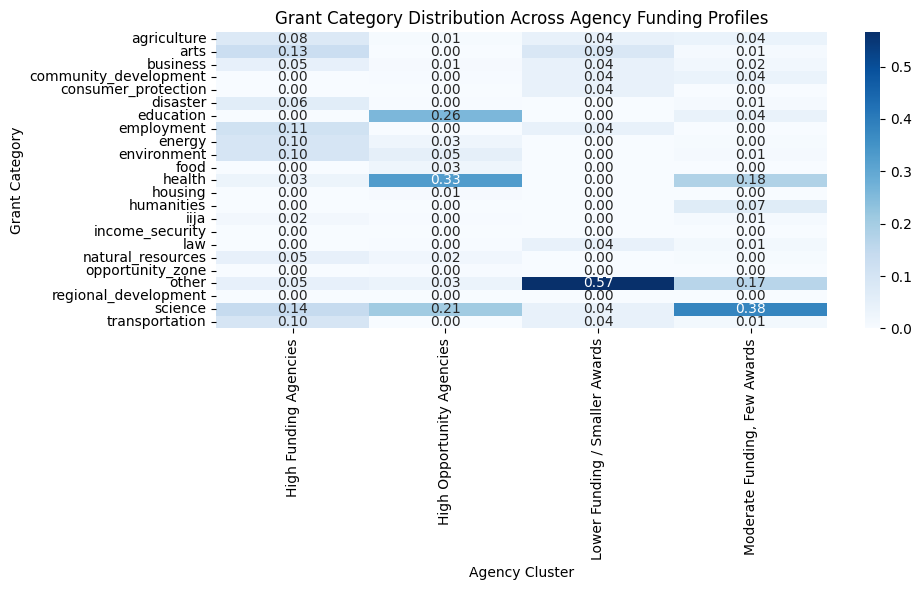

In [32]:
# Making results easier to interpret

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt='.2f', cmap='Blues')

plt.title("Grant Category Distribution Across Agency Funding Profiles")
plt.xlabel("Agency Cluster")
plt.ylabel("Grant Category")
plt.tight_layout()
plt.show()

**This heatmap reveals distinct funding patterns across agency strategy profiles. High Opportunity Agencies have 33% of their grants in health and 26% in education, suggesting these agencies prioritize social service delivery. However, High Funding Agencies distribute more evenly across categories including science, environment, and transportation, indicating broader portfolio strategies. Lower Funding agencies skew heavily toward miscellaneous 'other' categories with 57%, reflecting possibly smaller niche agencies without a clear category. These patterns were only visible through integration of agency level clustering with grant category data whcih produced really interesting and insightful results.**

## **3) Anna's Temporal Era Findings & Agency Funding Relation:**

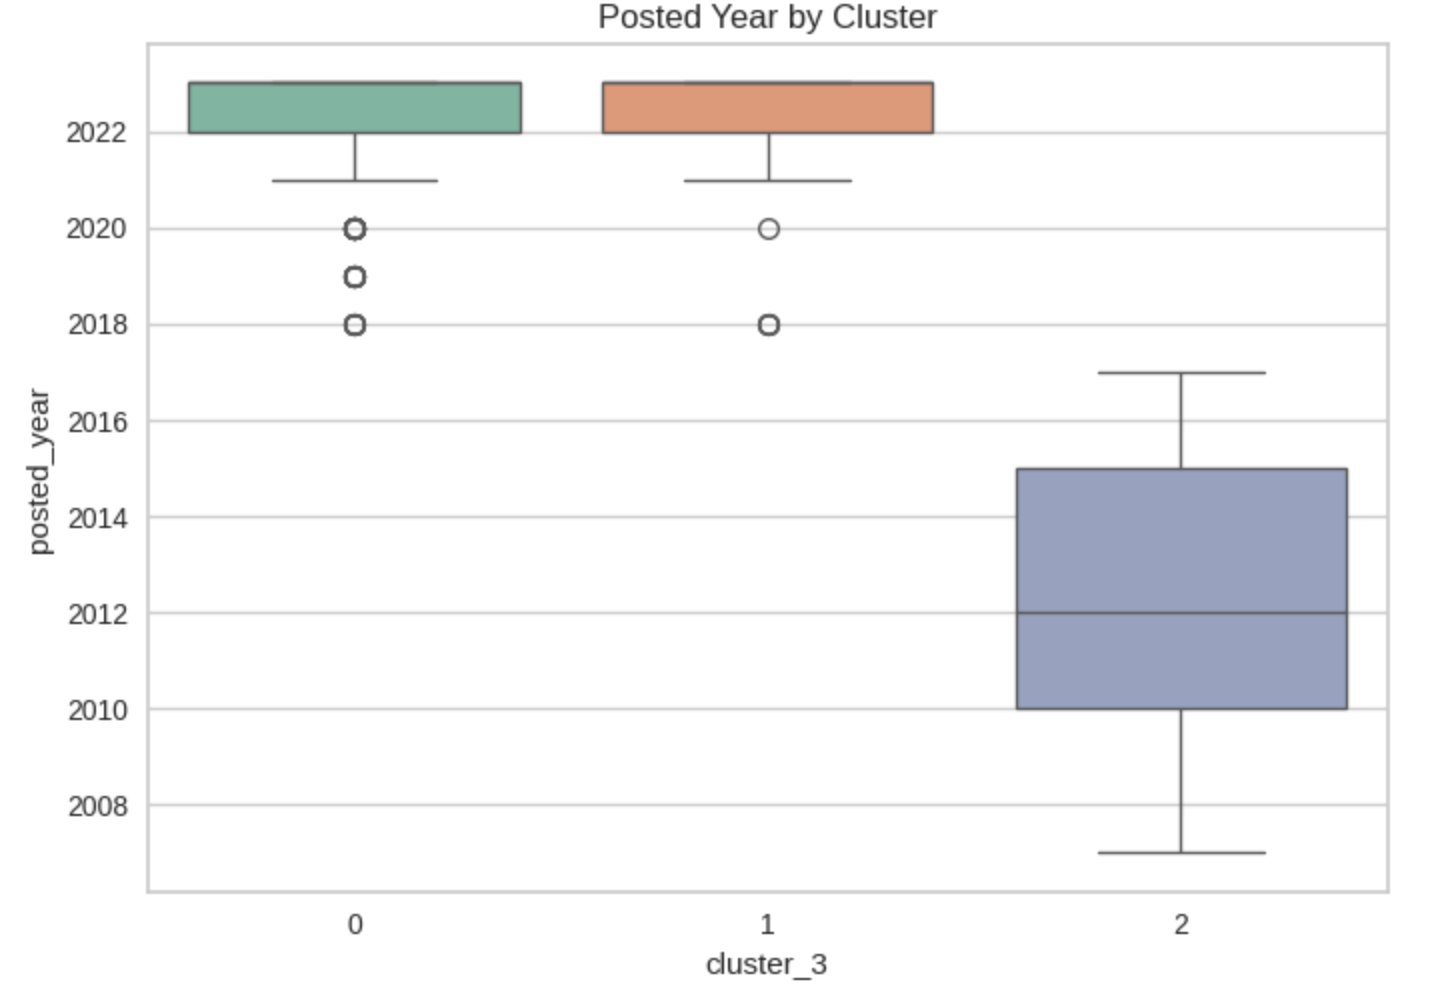

**Anna identified three temporal eras (shown above): Clusters 0 & 1
representing modern grants (2018-2023) and Cluster 2 representing
the pre-2018 period.**



In [33]:
# Seeing if Agency Funding Profiles Differ Across Eras

# Need to recreate Anna's era definitions based on her k=3 results
# Notes from her analysis for interpretation:
#     Cluster 0: Modern Science & Environment (2018-2023) - median ~2021
#     Cluster 1: Established Health NIH Era - median ~2019
#     Cluster 2: Older/Pre-Modern Era - median ~2012

# Create simple era bins
grants_with_year = grants_with_agency_cluster.copy()
grants_with_year['posted_year'] = pd.to_datetime(grants['posted_date'], errors='coerce').dt.year

def assign_era(year):
    if pd.isna(year):
        return None
    elif year < 2018:
        return "Pre-2018 Era (Cluster 2)"
    else:
        return "Modern Era 2018+ (Clusters 0&1)"

grants_with_year['era'] = grants_with_year['posted_year'].apply(assign_era)

# Remove NAs (this is what she did in her analysis)
grants_with_year_clean = grants_with_year.dropna(subset=['era', 'cluster_label'])

# Cross-tabulate agency clusters by era
era_agency_crosstab = pd.crosstab(grants_with_year_clean['cluster_label'],
                                  grants_with_year_clean['era'],
                                  normalize='columns')

print("Agency Funding Profile Distribution Across Anna's Eras \n")
print(era_agency_crosstab.round(3))
print()

# Calculate the change
print("Change from Pre-2018 to Modern Era")
if 'Pre-2018 Era (Cluster 2)' in era_agency_crosstab.columns and 'Modern Era 2018+ (Clusters 0&1)' in era_agency_crosstab.columns:
    change = era_agency_crosstab['Modern Era 2018+ (Clusters 0&1)'] - era_agency_crosstab['Pre-2018 Era (Cluster 2)']
    print(change.sort_values(ascending=False))

Agency Funding Profile Distribution Across Anna's Eras 

era                             Modern Era 2018+ (Clusters 0&1)  \
cluster_label                                                     
High Funding Agencies                                     0.046   
High Opportunity Agencies                                 0.738   
Lower Funding / Smaller Awards                            0.051   
Moderate Funding, Few Awards                              0.164   

era                             Pre-2018 Era (Cluster 2)  
cluster_label                                             
High Funding Agencies                              0.030  
High Opportunity Agencies                          0.837  
Lower Funding / Smaller Awards                     0.017  
Moderate Funding, Few Awards                       0.116  

Change from Pre-2018 to Modern Era
cluster_label
Moderate Funding, Few Awards      0.048485
Lower Funding / Smaller Awards    0.034368
High Funding Agencies             0.015817
High Op

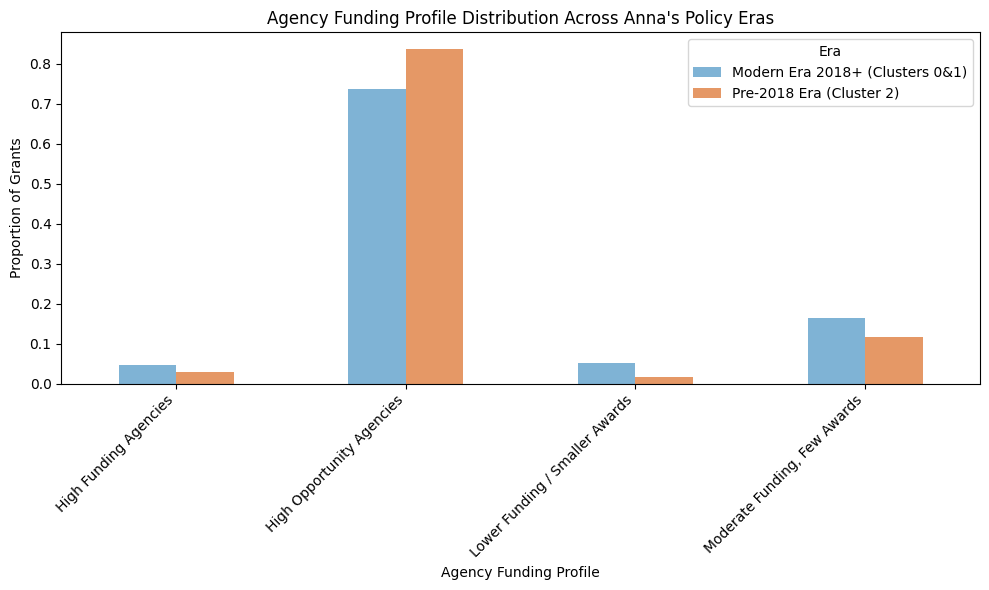

In [34]:
# Put the Potential Shifts into Bar Chart

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
era_agency_crosstab.plot(kind='bar', ax=ax, color=['#7FB3D5', '#E59866'])

plt.title("Agency Funding Profile Distribution Across Anna's Policy Eras")
plt.xlabel("Agency Funding Profile")
plt.ylabel("Proportion of Grants")
plt.legend(title="Era", loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**I was curious to test whether Anna's temporal eras align with shifts in agency funding behavior. So I analyzed how the distribution of agency funding profiles changed across her identified policy periods. The integration reveals a measurable structural shift: High Opportunity Agencies characterized by high grant volume and moderate per-award funding dominated both eras but declined from 84% of grants in the Pre-2018 Era to 74% in the Modern Era (2018+). Similarly, Moderate Funding / Few Awards agencies increased from 12% to 16%, representing a 4.8 percentage-point gain. This reallocation demonstrates that Anna's temporal clustering and my agency strategy profiles are not independent dimensions - federal grantmaking evolved both in when grants were posted and how agencies structured their distribution strategies. The shift suggests that post-2018, federal funding moved slightly toward concentration (fewer, larger targeted awards) rather than broad distribution (many smaller opportunities), potentially reflecting policy responses to major events like COVID-19 and infrastructure investment priorities.**

## **4) Sambisha's Eligibility Archetype Findings & Relation to Agendy Funding Strategies**

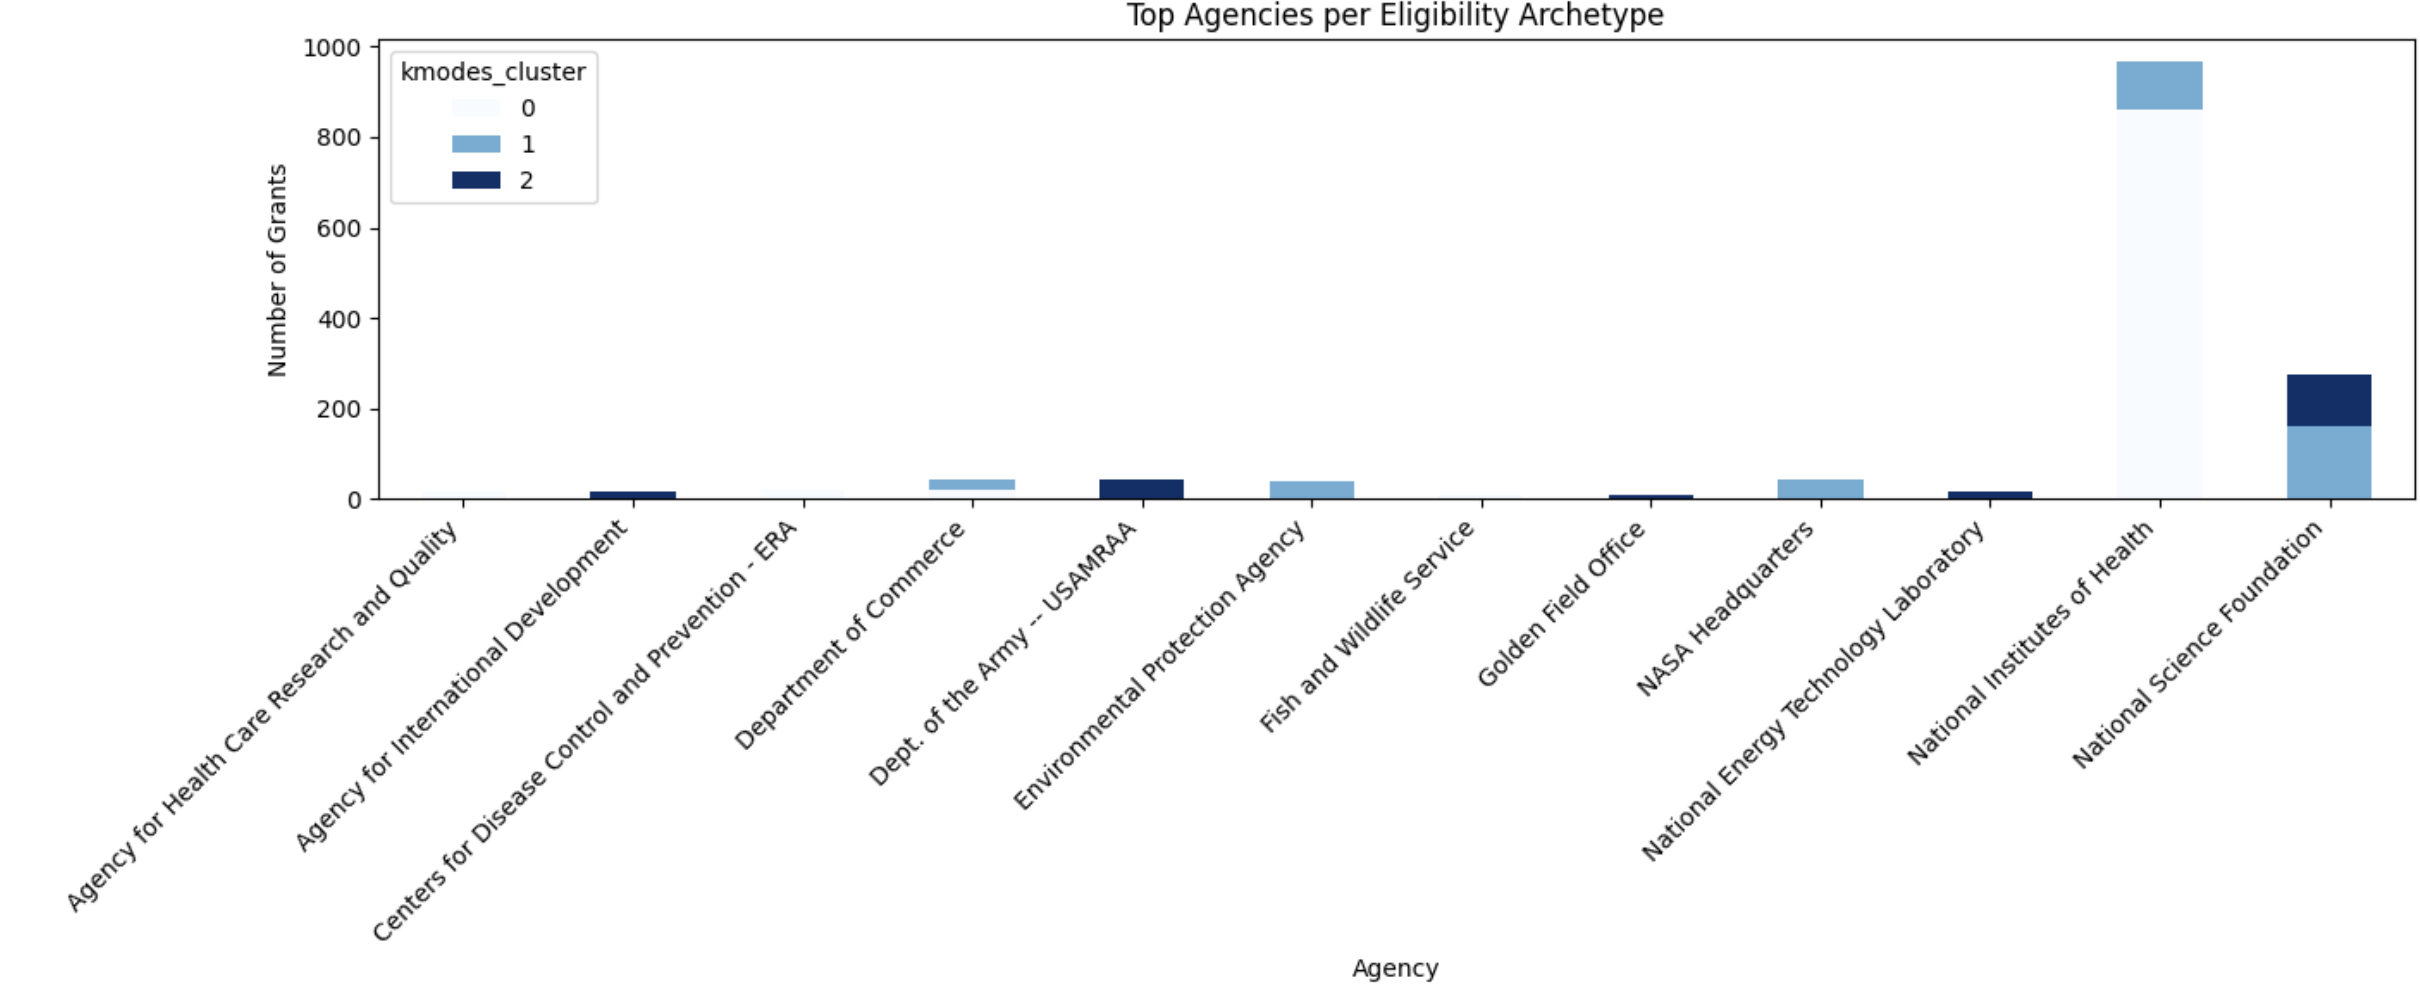

**Sambisha's chart reveals that NIH dominates Cluster 0 (Broad Institutional Eligibility) with nearly 950 grants, while NSF appears across multiple eligibility clusters. To quantify how eligibility breadth varies across agency funding profiles, I calculated the average number of eligibility types allowed per cluster.**


**I want to anwser the question: "Do High Funding Agencies allow more/fewer eligibility types than High Opportunity Agencies?"**

In [35]:
# Got eligibility columns from details
elig_cols = [col for col in details.columns if col.startswith('eligibility_')]

# Merged details with my agency clusters (similar concept to what I did with Maggie's clusters)
details_with_agency = details.merge(grants_with_agency_cluster[['opportunity_id', 'cluster_label']], on='opportunity_id', how='inner')

# Calculated average eligibility breadth per agency cluster
details_with_agency['eligibility_count'] = details_with_agency[elig_cols].sum(axis=1)

eligibility_by_cluster = details_with_agency.groupby('cluster_label')['eligibility_count'].agg(['mean', 'median', 'std'])

print("Average Eligibility Breadth by Agency Funding Profile")
print(eligibility_by_cluster.round(2))

Average Eligibility Breadth by Agency Funding Profile
                                mean  median   std
cluster_label                                     
High Funding Agencies           4.13     1.0  4.09
High Opportunity Agencies       9.04    15.0  6.73
Lower Funding / Smaller Awards  1.48     1.0  1.34
Moderate Funding, Few Awards    2.74     1.0  3.73


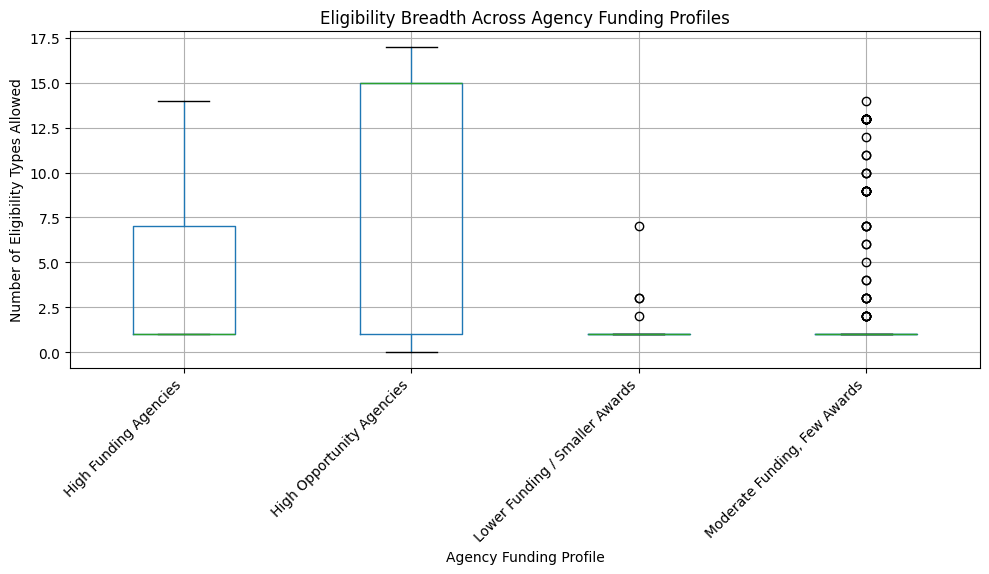

In [36]:
# Visualized it with box plot
import matplotlib.pyplot as plt

details_with_agency.boxplot(column='eligibility_count', by='cluster_label',figsize=(10, 6))

plt.suptitle('')  # This is to remove default title
plt.title('Eligibility Breadth Across Agency Funding Profiles')
plt.xlabel('Agency Funding Profile')
plt.ylabel('Number of Eligibility Types Allowed')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

**Key Finding: High Opportunity Agencies allow 9.04 eligibility types on average (median 15)**

**To quantitatively test the relationship between agency funding strategies and eligibility requirements, I calculated the average eligibility breadth (number of applicant types allowed) across agency funding profiles. The analysis reveals a really interesting pattern: High Opportunity Agencies - characterized by high grant volume and moderate per-award funding - allow an average of 9.04 eligibility types (median 15), making them the most inclusive cluster by far. This directly confirms Sambisha's finding that NIH, which dominates this funding profile, operates under broad institutional eligibility.**

**In contrast, Lower Funding / Smaller Awards agencies average only 1.48 eligibility types (median 1), suggesting highly restrictive or specialized grant programs. The boxplot visualization shows the amount of variance here with  High Opportunity Agencies displaying wide variation in eligibility breadth (with some grants allowing 17+ types), while smaller agencies cluster tightly around minimal eligibility. I beleive this to show that very volume focused agencies pair broad access with moderate awards, while concentrated funders impose stricter eligibility requirements.**

## **5) Integration Reflection:**

**This part of the projects process revealed many new insights that would not have been possible without integration. By connecting agency funding profiles to Anna's temporal eras, I demonstrated that federal grantmaking strategies have measurably shifted over time - with High Opportunity Agencies declining from 84% to 74% post-2018, suggesting a move toward concentrated funding rather than distributed funding. Similarly, linking agency clusters to Sambisha's eligibility work uncovered a clear structural relationship: volume focused agencies (mean 9.04 eligibility types) pursue broad institutional access, while concentrated funders restrict eligibility (mean 1.48 types). These cross examination patterns suggest that agency strategy probably coordinates on a set of behaviors spanning from funding amounts, temporal responses to policy priorities, and applicant accessibility.**

**The primary integration challenge was the structural incompatibility between the grants table (74,669 rows) and details table (2,000 rows), limiting direct joins to only 2 - 3% of observations. This meant integrations with Maggie's topic clusters and Sambisha's eligibility archetypes necessarily operated on a smaller, potentially non-representative sample. Future work could validate these patterns by collecting more complete grant description and eligibility data across the full dataset, or by testing whether the 2,000 row sample systematically over represents certain agencies or time periods.**

**Next steps our group could do: (1) testing whether High Funding Agencies shifted composition across Anna's eras to determine if funding concentration is structurally stable or event responsive, (2) applying Maggie's text embedding approach specifically to the 'other' category grants (57% of Lower Funding agencies) to reveal hidden niche sub topics, and (3) incorporating eligibility breadth directly into agency clustering features to produce richer strategy profiles that capture both funding behavior and grant access at the same time.**